<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Session 4: Vector Semantics and Embeddings

**University of Maryland, College Park**  
**Fall 2026**  
**Instructor**: Armin Mehrabian  
**Date**: September 22, 2026


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Introduction

*Nets are for fish;*  
*Once you get the fish, you can forget the net.*  
*Words are for meaning;*  
*Once you get the meaning, you can forget the words*

- **Zhuangzi (庄子)**, Chapter 26

# Distributional Hypothesis

**The idea:** words that show up in similar contexts tend to have similar meanings.

> "You shall know a word by the company it keeps." - **Firth (1957)**

So to learn what a word means, we can look at the words it appears next to.

- First proposed by Joos (1950), Harris (1954), and Firth (1957).


# Distributional Hypothesis: Guess the Word

You have never seen the word **bardiwac**, but you read:

- *A glass of ___, please.*
- *This ___ is a little too sweet.*
- *We opened a bottle of ___ with dinner.*
- *Don't drink ___ before you drive.*

From the company it keeps, you can already tell **bardiwac is a drink, probably a wine** - even though no one gave you a definition.


# What Should a Word Vector Capture?

Before we build vectors, let's name the meaning relations we want them to reflect:

- **senses** (one word, several meanings) and **synonymy** (same meaning)
- **similarity** (*cat* / *dog*) and **relatedness** (*coffee* / *cup*)
- **frames** (*buy* / *sell*) and **connotation** (positive / negative feeling)

A good representation should place related words **near each other** in space.


# Lexical Semantics: Lemmas and Senses

**Mouse** (N)
1. any of numerous small rodents...
2. a hand-operated device that controls a cursor...

**Mouse** is the lemma for the forms **mouse** and **mice**.

**Word sense**: each distinct meaning of a word is a separate *sense* (the rodent vs. the device).


# Lexical Semantics: Synonyms

**Synonyms** - two words whose senses are identical or nearly identical:

- couch / sofa
- vomit / throw up
- filbert / hazelnut
- car / automobile
- H₂O / water

Even "perfect" synonyms usually differ in register or connotation.


# Lexical Semantics: Word Similarity

Few words have true synonyms, but many are **similar**: *cat* and *dog* are not the same, yet clearly alike.

Humans can score similarity (SimLex-999, Hill et al., 2015):

| Word 1 | Word 2 | Score (0-10) |
|--------|--------|-------|
| vanish | disappear | 9.8 |
| belief | impression | 5.95 |
| muscle | bone | 3.65 |
| modest | flexible | 0.98 |
| hole | agreement | 0.3 |

source: https://fh295.github.io/simlex.html


# Lexical Semantics: Word Relatedness

**Related** words are not similar, but belong together - they co-occur in the same situations (a **semantic field**).

- **Co-participation**: *coffee* and *cup*
- **Same event**: *scalpel* and *surgeon*
- **Semantic field**:
  - hospital: surgeon, scalpel, nurse, anesthetic
  - restaurant: waiter, menu, plate, chef

Note: *coffee* and *cup* are **related** but not **similar** - vectors capture both, which is sometimes a feature and sometimes a bug.


# Lexical Semantics: Semantic Frames and Roles

A **semantic frame** is a set of words describing one type of event from different perspectives:

- **buy** (buyer's view), **sell** (seller's view), **pay** (the money)

Sharing a frame lets us paraphrase:

- *Sam bought the book from Ling* = *Ling sold the book to Sam*


# Lexical Semantics: Connotation

**Connotation** is the *feeling* a word carries - its emotional coloring, layered on top of its literal meaning (*slim* vs. *scrawny* point to the same thing but feel different).

- positive: *wonderful*, *great*, *love*  vs.  negative: *dreary*, *terrible*, *hate*
- near-synonyms can differ in feeling: *copy* / *replica* / *knock-off*

**Connotation is a word's affective meaning** - and Osgood (1957) showed we can *measure* it along three axes:

- **valence**: pleasant <-> unpleasant
- **arousal**: calm <-> excited
- **dominance**: controlled <-> in-control

So each word becomes a **3-D affect vector** (e.g. *terrific* = high, high, high) - an early ancestor of the embeddings later in this lecture.


# Learning a Word From Its Contexts

You have never seen the word *ongchoi*, but you read:

*Ongchoi is delicious sauteed with garlic.*  
*Ongchoi is superb over rice.*  
*... ongchoi leaves with salty sauces ...*

And elsewhere you have seen those same context words:

*... spinach sauteed with garlic over rice ...*  
*... chard stems and leaves are delicious ...*  
*... collard greens and other salty leafy greens ...*

Same contexts as *spinach* and *chard* -> *ongchoi* must be a leafy green. **This is the distributional hypothesis at work, and the basis for turning words into vectors.**


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 1. Sparse Vector Representation



# Words and Vectors

**Vectors** or the **Distributional model** of word meaning is based on a co-occurrence matrix, a way to represent how often two words co-occur. Two popular matrices:

- **Term-document co-occurrence matrix**
- **Term-term co-occurrence matrix**

## Term-Document Co-occurrence Matrix  
Example:  
Two docs →  
- Doc1: *I like NLP*  
- Doc2: *NLP is fun*

| Term | Doc1 | Doc2 |
|------|------|------|
| I    | 1 | 0 |
| like | 1 | 0 |
| NLP  | 1 | 1 |
| is   | 0 | 1 |
| fun  | 0 | 1 |

Each word is a vector of document frequencies.

## Term-Term Co-occurrence Matrix  
Example text: *I like NLP. NLP is fun.*

|     | I | like | NLP | is | fun |
|-----|---|------|-----|----|-----|
| I   | 0 | 1 | 1 | 0 | 0 |
| like| 1 | 0 | 1 | 0 | 0 |
| NLP | 1 | 1 | 0 | 1 | 1 |
| is  | 0 | 0 | 1 | 0 | 1 |
| fun | 0 | 0 | 1 | 1 | 0 |

Each word is represented by how often it appears near others.

# A Real Example: Shakespeare

Four words counted across four of Shakespeare's plays (the columns).

- A **vector** is just a list of numbers.
- Read **down a column**: *Julius Caesar* -> [7, 62, 1, 2] (its counts of battle, good, fool, wit).
- Read **across a row**: each **word** becomes a vector over documents.


In [2]:
# Term-document matrix example from Shakespeare's plays
shakespeare_matrix = pd.DataFrame({
    'As You Like It': [1, 114, 36, 20],
    'Twelfth Night': [0, 80, 58, 15],
    'Julius Caesar': [7, 62, 1, 2],
    'Henry V': [13, 89, 4, 3]
}, index=['battle', 'good', 'fool', 'wit'])

print("Term-Document Matrix (Shakespeare's Plays)")
print("="*60)
print(shakespeare_matrix)
print("\nColumn vector for 'Julius Caesar':")
print(shakespeare_matrix['Julius Caesar'].values)

Term-Document Matrix (Shakespeare's Plays)
        As You Like It  Twelfth Night  Julius Caesar  Henry V
battle               1              0              7       13
good               114             80             62       89
fool                36             58              1        4
wit                 20             15              2        3

Column vector for 'Julius Caesar':
[ 7 62  1  2]


# Visualizing Word Vectors

Word embeddings can be projected into a lower-dimensional space (e.g. 2D) using **t-SNE** to visualize semantic relationships between words. Similar words cluster together - here positive-sentiment words (green), negative-sentiment words (red), and neutral / function words (blue).

<p align="center">
  <img src="img/tsne_vector_semantics.png" width="90%">
</p>

Below we build the same idea live: take the four context vectors from the previous slide, **L2-normalize** them (direction, not magnitude - the cosine idea), and project to 2D with PCA. The food words and tech words separate.


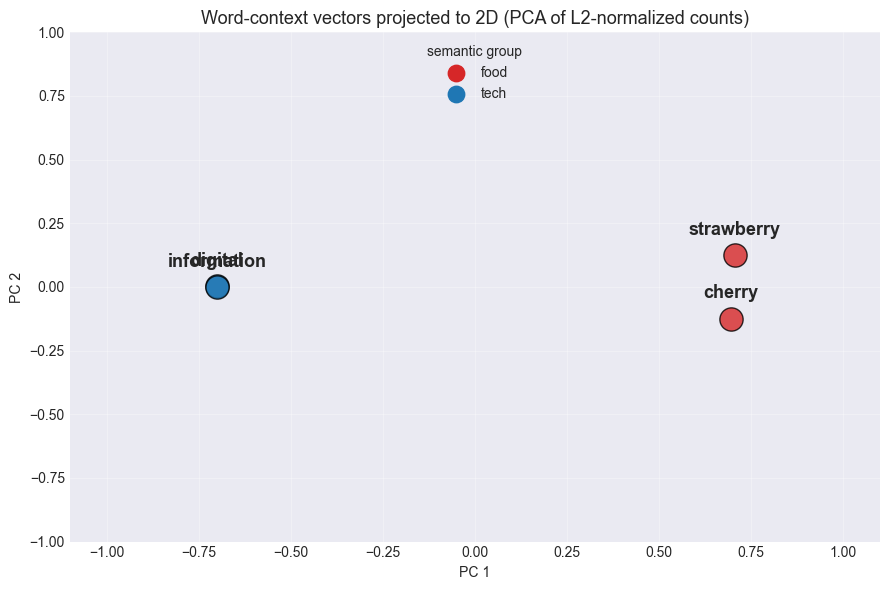

In [3]:
# Project the word-context vectors from the previous slide down to 2D.
# We L2-normalize first, so distance reflects direction (cosine), not magnitude.
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

words = ['cherry', 'strawberry', 'digital', 'information']
# context dimensions: [aardvark, computer, data, result, pie, sugar]
context_counts = np.array([
    [0,    2,    8,    9,  442, 25],   # cherry
    [0,    0,    0,    1,   60, 19],   # strawberry
    [0, 1670, 1683,   85,    5,  4],   # digital
    [0, 3325, 3982,  378,    5, 13],   # information
], dtype=float)

coords = PCA(n_components=2).fit_transform(normalize(context_counts))

groups = ['food', 'food', 'tech', 'tech']
palette = {'food': '#d62728', 'tech': '#1f77b4'}

fig, ax = plt.subplots(figsize=(9, 6))
for (x, y), w, g in zip(coords, words, groups):
    ax.scatter(x, y, s=280, color=palette[g], alpha=0.8, edgecolor='k', zorder=3)
    ax.annotate(w, (x, y), fontsize=13, fontweight='bold', ha='center',
                va='bottom', xytext=(0, 12), textcoords='offset points')

for g, c in palette.items():
    ax.scatter([], [], color=c, s=140, label=g)
ax.legend(title='semantic group', loc='upper center')
ax.set_title('Word-context vectors projected to 2D (PCA of L2-normalized counts)', fontsize=13)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


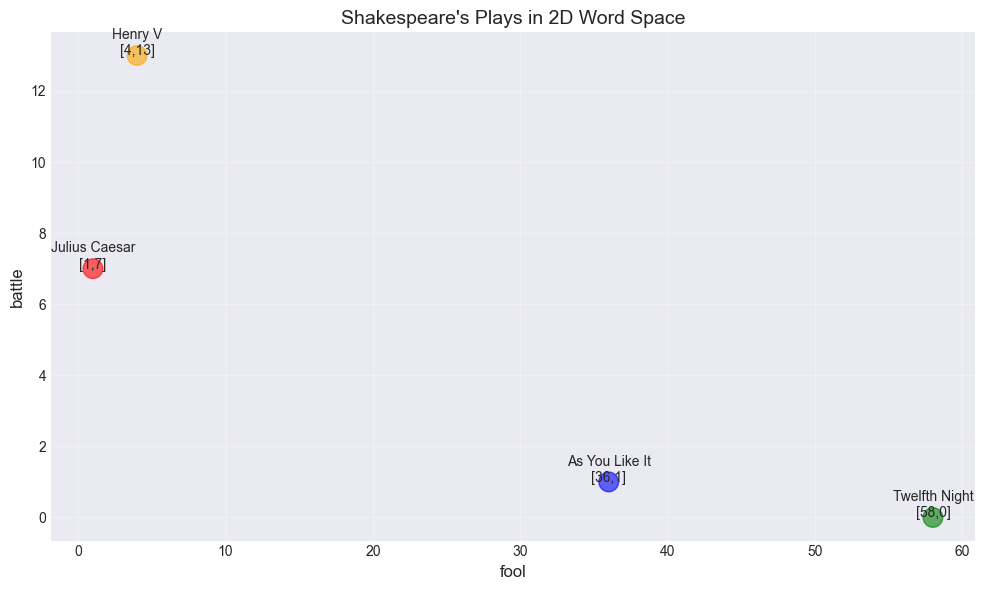

In [4]:
# Visualize documents in 2D space (using 'fool' and 'battle' dimensions)
fig, ax = plt.subplots(figsize=(10, 6))

x_coords = shakespeare_matrix.loc['fool'].values
y_coords = shakespeare_matrix.loc['battle'].values
labels = shakespeare_matrix.columns

ax.scatter(x_coords, y_coords, s=200, alpha=0.6, c=['blue', 'green', 'red', 'orange'])

for i, label in enumerate(labels):
    ax.annotate(f"{label}\n[{x_coords[i]},{y_coords[i]}]", 
                (x_coords[i], y_coords[i]),
                fontsize=10, ha='center')

ax.set_xlabel('fool', fontsize=12)
ax.set_ylabel('battle', fontsize=12)
ax.set_title("Shakespeare's Plays in 2D Word Space", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Words as Vectors: Document Dimensions

In a term-document matrix each **word** is a **row** - a vector whose dimensions are the documents.

**battle** -> [1, 0, 7, 13]  (counts across the four plays)

Two words are similar if they appear in the **same documents**.


In [5]:
# Extract row vectors (words as vectors in document space)
print("Words as Vectors (Document Dimensions)")
print("="*60)
for word in shakespeare_matrix.index:
    vec = shakespeare_matrix.loc[word].values
    print(f"{word:10} -> {vec}")

Words as Vectors (Document Dimensions)
battle     -> [ 1  0  7 13]
good       -> [114  80  62  89]
fool       -> [36 58  1  4]
wit        -> [20 15  2  3]


# Words as Vectors: Word Dimensions

A sharper idea: let the dimensions be **other words** that appear nearby (a context window of ±4 words).

Sample contexts:
- ... traditionally followed by **cherry** pie ...
- ... such as **strawberry** rhubarb pie ...
- ... personal **digital** assistants ...
- ... **information** available on the internet ...

Now two words are similar if they share the **same neighbors**.


# Words as Vectors: A Real Co-occurrence Table

Co-occurrence counts for four words over a few context-word dimensions (Wikipedia):

| Word | aardvark | ... | computer | data | result | pie | sugar | ... |
|------|----------|-----|----------|------|--------|-----|-------|-----|
| cherry | 0 | ... | 2 | 8 | 9 | 442 | 25 | ... |
| strawberry | 0 | ... | 0 | 0 | 1 | 60 | 19 | ... |
| **digital** | **0** | **...** | **1670** | **1683** | **85** | **5** | **4** | **...** |
| information | 0 | ... | 3325 | 3982 | 378 | 5 | 13 | ... |

*cherry* / *strawberry* cluster near *pie* and *sugar*; *digital* / *information* cluster near *computer* and *data*.


# Words as Vectors: Two Dimensions at a Time

We cannot draw a 20,000-dimensional vector, but we can plot any **two** dimensions. Here: *digital* and *information* using only their **data** and **computer** counts.


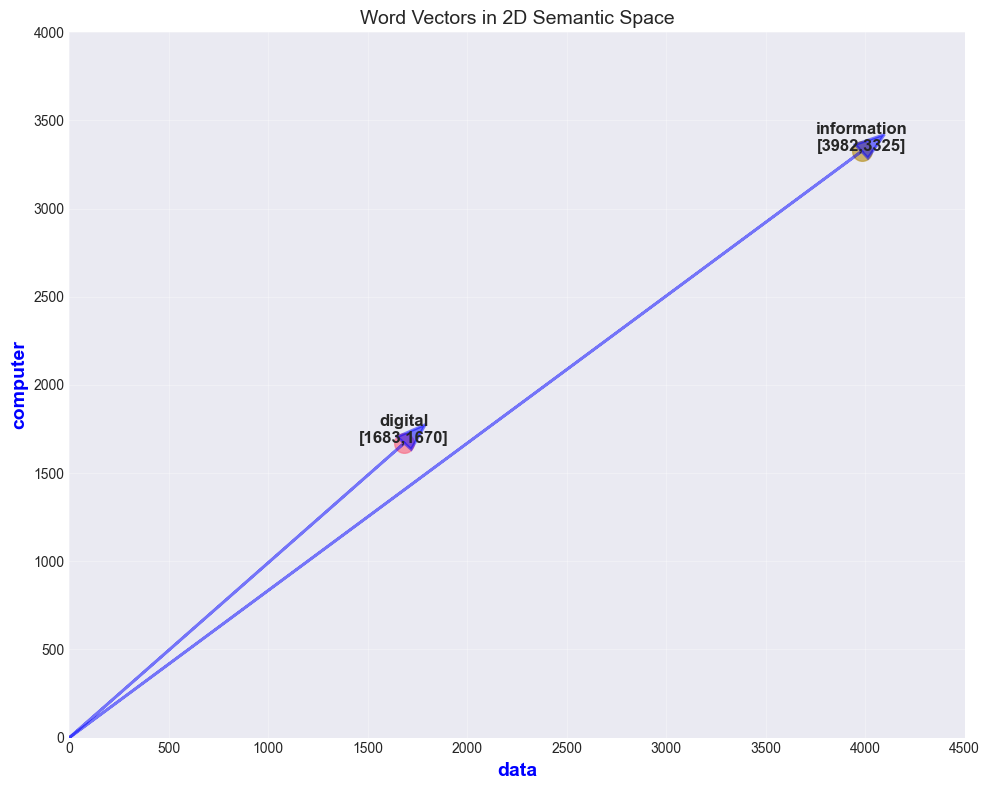

In [6]:
# Simulate word vectors in 2D space (data vs computer dimensions)
word_vectors_2d = {
    'digital': [1683, 1670],
    'information': [3982, 3325]
}

fig, ax = plt.subplots(figsize=(10, 8))

for word, coords in word_vectors_2d.items():
    ax.scatter(coords[0], coords[1], s=200, alpha=0.7)
    ax.annotate(f"{word}\n[{coords[0]},{coords[1]}]", 
                coords, fontsize=12, ha='center', fontweight='bold')
    # Draw arrow from origin
    ax.arrow(0, 0, coords[0], coords[1], head_width=100, head_length=150, 
             fc='blue', ec='blue', alpha=0.5, linewidth=2)

ax.set_xlabel('data', fontsize=14, fontweight='bold', color='blue')
ax.set_ylabel('computer', fontsize=14, fontweight='bold', color='blue')
ax.set_title('Word Vectors in 2D Semantic Space', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 4500)
ax.set_ylim(0, 4000)
plt.tight_layout()
plt.show()

# Cosine Similarity: Measuring Closeness

Two words are similar when their vectors point the **same way**. Cosine similarity measures the **angle** between them:

- same direction -> angle 0° -> **cosine = 1** (very similar)
- perpendicular -> angle 90° -> **cosine = 0** (unrelated)

**Why the angle, not the distance?** A long document repeats words, so its count vector gets *longer* - but not more different in meaning. The angle ignores length and looks only at *direction*.

$$\text{cosine}(\mathbf{v},\mathbf{w}) = \frac{\mathbf{v}\cdot\mathbf{w}}{|\mathbf{v}|\,|\mathbf{w}|}$$

- numerator $\mathbf{v}\cdot\mathbf{w}=\sum_i v_i w_i$: how much the two vectors **align**
- denominator $|\mathbf{v}|\,|\mathbf{w}|$: divides out each vector's **length**

For word counts (never negative) cosine runs from **0** (share no contexts) to **1** (identical direction).


# Cosine Similarity: The Geometric Picture

Three words in the 2D space of *computer* and *pie* counts. *digital* and *information* point almost the **same way** (small angle -> cosine near 1); *cherry* points elsewhere (large angle -> cosine near 0). The demo below computes them.


In [7]:
# Cosine similarity demonstration
def cosine_sim(v1, v2):
    """Calculate cosine similarity between two vectors"""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

# Example vectors (pie, data, computer dimensions)
cherry = np.array([442, 8, 2])
digital = np.array([5, 1683, 1670])
information = np.array([5, 3982, 3325])

print("Cosine Similarity Examples")
print("="*60)
print(f"cherry vector:      {cherry}")
print(f"digital vector:     {digital}")
print(f"information vector: {information}")
print()
print(f"cos(cherry, information) = {cosine_sim(cherry, information):.3f}")
print(f"cos(digital, information) = {cosine_sim(digital, information):.3f}")
print(f"cos(cherry, digital) = {cosine_sim(cherry, digital):.3f}")

Cosine Similarity Examples
cherry vector:      [442   8   2]
digital vector:     [   5 1683 1670]
information vector: [   5 3982 3325]

cos(cherry, information) = 0.018
cos(digital, information) = 0.996
cos(cherry, digital) = 0.018


# TF-IDF: The Idea

Raw counts over-value words that are merely common. A word describes a document well when it is:

- **frequent in this document**, and
- **rare across other documents**.

TF-IDF multiplies these two signals.

**Term Frequency (TF)** - how often term $t$ appears in document $d$:
$$\text{tf}_{t,d} = \text{count}(t,d) \;\longrightarrow\; 1 + \log_{10}\text{count}(t,d)$$

We take the **log** because 1 -> 10 occurrences matters far more than 1000 -> 1010. A count of 0 stays 0.


# TF-IDF: Down-weighting Common Words

**Inverse Document Frequency (IDF)** - how *rare* a term is across the corpus:
$$\text{idf}_t = \log_{10}\frac{N}{\text{df}_t}$$

- $N$ = number of documents, $\text{df}_t$ = documents that contain $t$
- in **every** document -> $\text{df}_t = N$ -> $\text{idf}_t = \log_{10}1 = 0$
- **rare** word -> small $\text{df}_t$ -> large idf

**Put together:** $\;w_{t,d} = \text{tf}_{t,d}\times\text{idf}_t$

*"the"* is everywhere -> idf ≈ 0 -> killed. *"economy"* is frequent in a business article but rare elsewhere -> high tf-idf.


# TF-IDF: Weighing terms in the vector

A tf-idf weighted term-document matrix for four words in four Shakespeare plays (J&M, *Speech and Language Processing*, Fig. 6.9). The document frequencies are computed over the **full 37-play** First Folio; only four plays are shown here.

| Word | As You Like It | Twelfth Night | Julius Caesar | Henry V |
|------|----------------|---------------|---------------|---------|
| battle | 0.074 | 0 | 0.22 | 0.28 |
| good | 0 | 0 | 0 | 0 |
| fool | 0.019 | 0.021 | 0.0036 | 0.0083 |
| wit | 0.049 | 0.044 | 0.018 | 0.022 |

**Why is "good" zero everywhere?** It appears in all 37 plays, so its idf = log₁₀(37/37) = 0. A word that occurs in every document has no power to discriminate between them - which is exactly what tf-idf is designed to down-weight.


In [8]:
# TF-IDF the textbook way, using the exact formulas from the previous slides:
#   tf  = 1 + log10(count)   (and 0 when count == 0)
#   idf = log10(N / df)      (N = number of documents, df = docs containing the term)

counts = shakespeare_matrix.values.astype(float)   # 4 words x 4 plays
N = counts.shape[1]                                 # N = 4 documents

df  = (counts > 0).sum(axis=1)                      # document frequency per word
idf = np.log10(N / df)                              # inverse document frequency

# log-scaled term frequency (keep exact zeros at 0, avoid log10(0))
tf = np.where(counts > 0, 1 + np.log10(np.where(counts > 0, counts, 1)), 0.0)
tfidf = tf * idf[:, None]

summary = pd.DataFrame({'df (of N=4)': df.astype(int),
                        'idf = log10(N/df)': idf.round(3)},
                       index=shakespeare_matrix.index)
tfidf_df = pd.DataFrame(tfidf, index=shakespeare_matrix.index,
                        columns=shakespeare_matrix.columns)

print('Per-word document frequency and idf:')
print(summary.to_string())
print('\nTF-IDF weighted term-document matrix (this 4-play corpus):')
print(tfidf_df.round(3))
print('\nWithin just these 4 plays, good/fool/wit occur in all four, so')
print('idf = log10(4/4) = 0 and their weights vanish - only "battle" (absent')
print('from Twelfth Night) survives. Computing df over all 37 plays, as in the')
print('table above, restores small nonzero weights for fool and wit.')


Per-word document frequency and idf:
        df (of N=4)  idf = log10(N/df)
battle            3              0.125
good              4              0.000
fool              4              0.000
wit               4              0.000

TF-IDF weighted term-document matrix (this 4-play corpus):
        As You Like It  Twelfth Night  Julius Caesar  Henry V
battle           0.125            0.0          0.231    0.264
good             0.000            0.0          0.000    0.000
fool             0.000            0.0          0.000    0.000
wit              0.000            0.0          0.000    0.000

Within just these 4 plays, good/fool/wit occur in all four, so
idf = log10(4/4) = 0 and their weights vanish - only "battle" (absent
from Twelfth Night) survives. Computing df over all 37 plays, as in the
table above, restores small nonzero weights for fool and wit.


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 2. Dense Vector Representation



# From Sparse to Dense

The vectors so far are **sparse**: length $|V|$ (20,000-50,000), almost all zeros.

- **Big and mostly empty** - one dimension per context word.
- **They miss similarity** - *car* and *automobile* get *different* dimensions, so their vectors barely overlap unless the words literally co-occur.

**Goal:** short (~100-300), **dense** vectors where similar words are automatically close. We do not count them - we **learn** them.


# Learning Vectors by Prediction

**Idea:** turn *"are these two words neighbors?"* into a task a network can learn.

- Context (window = 1) around *is* in "This **is** an example" -> *this*, *an*
- Build a classifier for (input word, output word) pairs:
  - **(is, this)**, **(is, an)** -> neighbors (label **1**)
  - **(is, example)**, **(is, another)** -> not neighbors (label **0**)
- Each word $i$ carries a trainable vector $\mathbf{w}_i \in \mathbb{R}^D$.

As the network gets better at predicting neighbors, it tunes these vectors - and $\mathbf{w}_i$ **becomes** the embedding of word $i$.


# The Big Picture: A Word Predicts Its Neighbors

<p align="center">
  <img src="img/word2vec_fasttext.png" width="85%">
</p>

We train a shallow network on a **fake task**: given a word (*drink*), predict the words around it (*juice*, *milk*). We do not care about the predictions. The prize is the narrow **hidden layer** - after training, each word's row of weights **is** its embedding. Word2Vec (Google) and FastText (Facebook) are built this way.


# Word2Vec: The Network

<p align="center">
  <img src="img/word2vec_architecture.png" width="55%">
</p>

- **Input**: one-hot vector for the current word (size $|V|$, e.g. 10,000).
- **Hidden**: a **linear** layer of ~300 units, **no activation**. Its weight matrix ($|V|\times300$) is a **lookup table** - row $i$ is the vector for word $i$.
- **Output**: softmax over the whole vocabulary, predicting nearby words.

After training we **keep the hidden weights** (the embeddings) and throw away the output layer.


# Word2Vec: CBOW vs. Skip-Gram

<p align="center">
  <img src="img/cbow_skipgram.png" width="65%">
</p>

Two ways to set up the prediction task:

**CBOW** (Continuous Bag of Words) - context -> center word
- "The cat ___ on the floor" -> **sat**
- averages the context; **faster**, better for **frequent** words

**Skip-Gram** - center word -> context
- **sat** -> "the", "cat", "on", "floor"
- each word makes several predictions -> more signal; better for **rare** words and small corpora


# Word2Vec: CBOW, Step by Step

Predict the missing center word: **"the cat ___ on floor"**

<p align="center">
  <img src="img/cbow_example.png" width="65%">
</p>

- **Input**: context words *the, cat, on, floor* (one-hot).
- $W_{V\times N}$ maps each to its $N$-dim vector; average them -> hidden.
- $W'_{N\times V}$ scores every vocabulary word; softmax -> predict **sat**.

We learn $W$ (input vectors) and $W'$ (output vectors); $N$ is the embedding size.


# Semantic Properties of Embeddings

<p align="center">
  <img src="img/semantic_math.png" width="65%">
</p>

- **(a)** *king* - *man* + *woman* ≈ *queen*
- **(b)** offsets capture comparative / superlative morphology (*slow -> slower -> slowest*)

**Why does the arithmetic work?** Relationships show up as **consistent directions**. The "male -> female" step is about the same vector for *king->queen*, *man->woman*, *uncle->aunt* - so removing *man* and adding *woman* slides *king* along that direction to land near *queen*.

*(Pennington et al., 2014)*


In [9]:
# Demonstrate word embeddings using a simple corpus
from gensim.models import Word2Vec
import nltk

# Sample corpus
sentences = [
    ['king', 'is', 'a', 'strong', 'man'],
    ['queen', 'is', 'a', 'wise', 'woman'],
    ['boy', 'is', 'a', 'young', 'man'],
    ['girl', 'is', 'a', 'young', 'woman'],
    ['prince', 'is', 'a', 'young', 'king'],
    ['princess', 'is', 'a', 'young', 'queen'],
    ['man', 'is', 'strong'],
    ['woman', 'is', 'pretty'],
    ['prince', 'is', 'a', 'boy', 'will', 'be', 'king'],
    ['princess', 'is', 'a', 'girl', 'will', 'be', 'queen']
]

# Train Word2Vec model
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=4, epochs=100)

# Test semantic relationships
print("Word2Vec Semantic Properties")
print("="*60)

try:
    result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
    print("\nAnalogy: king - man + woman ≈ ?")
    for word, score in result:
        print(f"  {word}: {score:.3f}")
    print("\nNote: with only 10 training sentences these scores are tiny and the")
    print("top result is essentially noise - not a reliable 'queen'. Reliable")
    print("analogies need a large corpus, as in the Reuters demo below.")
except KeyError:
    print("\nAnalogy: (need a larger corpus for reliable analogies)")


Word2Vec Semantic Properties

Analogy: king - man + woman ≈ ?
  prince: 0.153
  be: 0.098
  boy: 0.053

Note: with only 10 training sentences these scores are tiny and the
top result is essentially noise - not a reliable 'queen'. Reliable
analogies need a large corpus, as in the Reuters demo below.


In [10]:
# Demonstrate word embeddings using the Reuters news corpus
from gensim.models import Word2Vec
import nltk
from nltk.corpus import reuters

# Ensure required NLTK resources are present. Download only if missing, so we
# do not re-hit the network on every run (which can fail behind strict SSL).
# NLTK may keep a corpus unzipped (corpora/reuters) or zipped (corpora/reuters.zip),
# so we accept either layout before deciding to download.
def _ensure_nltk(resource, *candidate_paths):
    for path in candidate_paths:
        try:
            nltk.data.find(path)
            return
        except LookupError:
            continue
    nltk.download(resource, quiet=True)

_ensure_nltk('reuters', 'corpora/reuters', 'corpora/reuters.zip')
_ensure_nltk('punkt', 'tokenizers/punkt', 'tokenizers/punkt.zip')
_ensure_nltk('punkt_tab', 'tokenizers/punkt_tab', 'tokenizers/punkt_tab.zip')

# Load all sentences into memory (thread-safe)
sentences = list(reuters.sents())
print(f"Loaded {len(sentences)} sentences.")

# Train Word2Vec model.
# gensim 4.x + numpy 2.x prints a harmless "Exception ignored in ... our_dot_float"
# for each batch; we silence C-level stderr (fd 2) around training to keep the
# demo output clean. Results are unaffected.
import os, sys, io
from contextlib import contextmanager

@contextmanager
def _quiet_stderr():
    # The warning is an "unraisable exception" written to Python's sys.stderr,
    # so we swap that out; we also redirect the C-level fd (2) as a backstop.
    saved_py, saved_fd = sys.stderr, os.dup(2)
    devnull = os.open(os.devnull, os.O_WRONLY)
    try:
        sys.stderr = io.StringIO()
        os.dup2(devnull, 2)
        yield
    finally:
        sys.stderr = saved_py
        os.dup2(saved_fd, 2)
        os.close(devnull)
        os.close(saved_fd)

with _quiet_stderr():
    model = Word2Vec(
        sentences,
        vector_size=100,
        window=5,
        min_count=3,
        workers=4,
        sg=1,       # skip-gram for better semantics
        epochs=20
    )

# Word2Vec trained on Reuters - print semantic examples and embeddings
from pprint import pprint

# Check available vocabulary size
print(f"Vocabulary size: {len(model.wv.index_to_key)}")

# Show words most similar to 'market'
print("\nMost similar to 'market':")
pprint(model.wv.most_similar('market', topn=5))

# Analogy within the Reuters domain, e.g. "oil" - "energy" + "bank"
try:
    print("\nAnalogy: oil - energy + bank ≈ ?")
    result = model.wv.most_similar(positive=['oil', 'bank'], negative=['energy'], topn=5)
    pprint(result)
except KeyError:
    print("Analogy failed - some words not in corpus.")

# Show a sample embedding for one word
word = 'market'
print(f"\nEmbedding for '{word}' (first 10 dimensions):")
print(model.wv[word][:10])


Loaded 54716 sentences.
Vocabulary size: 19769

Most similar to 'market':
[('markets', 0.7051103711128235),
 ('pacemaker', 0.6199131608009338),
 ('fluctuating', 0.6132659316062927),
 ('bullish', 0.600831925868988),
 ('rigidly', 0.5993373990058899)]

Analogy: oil - energy + bank ≈ ?
[('central', 0.59098881483078),
 ('Bank', 0.5149902105331421),
 ('120', 0.5148786306381226),
 ('outright', 0.5114827156066895),
 ('banks', 0.5098334550857544)]

Embedding for 'market' (first 10 dimensions):
[ 0.28372446  0.3988892  -0.07833367  0.30788156  0.17782523  0.01048501
 -0.17642348  1.3265355  -0.22444035 -0.24045582]


# GloVe: Global Vectors

**There is no neural network here.** Word2Vec *predicts* a word's neighbors with a shallow net. GloVe simply **counts, then fits numbers to the counts**.

**1. Count** - over the whole corpus, build one big table $X$: how often does word $i$ occur near word $j$?

**2. Fit** - find a vector per word so that
$$\mathbf{w}_i \cdot \mathbf{w}_j \;\approx\; \log X_{ij}$$
> dot product of two word vectors ≈ log of how often they co-occur.

This is a plain **least-squares fit** to the count table (matrix factorization), not a prediction task. The idea that makes it work: meaning lives in co-occurrence **ratios** - unpacked on the next slide.


# GloVe: Why Co-occurrence Ratios?

Meaning is easier to see in a **ratio** than in a raw count. Take two related words, *ice* and *steam*, and a third "probe" word $k$; compare how often $k$ shows up near each:

$$\text{ratio} = \frac{P(k \mid \text{ice})}{P(k \mid \text{steam})}$$

| probe word $k$ | ratio | what it tells us |
|---|---|---|
| *solid*   | **8.9**   | much greater than 1  ->  belongs with **ice** |
| *gas*     | **0.085** | much less than 1  ->  belongs with **steam** |
| *water*   | **1.4**   | about 1  ->  goes with **both** |
| *fashion* | **0.96**  | about 1  ->  goes with **neither** |

*(actual values from Pennington et al., 2014)*

Read it this way: the ratio is **big** when the probe belongs to *ice*, **small** when it belongs to *steam*, and **near 1** when it cannot tell them apart. That single number isolates exactly what makes *ice* and *steam* different - the raw counts alone would not.

GloVe bakes this in: because $\log\frac{a}{b}=\log a-\log b$, fitting $\mathbf{w}_i\cdot\mathbf{w}_j \approx \log X_{ij}$ makes these **ratios** show up as simple **differences** between word vectors.


# FastText: Words Made of Subwords

Word2Vec treats each word as an **atom** - *play*, *plays*, *playing*, *player* are four unrelated symbols, each needing its own training examples.

**FastText** (Facebook, 2016) breaks every word into **character n-grams** (subwords), marking word boundaries with `<` and `>`:

*playing* (n = 3) ->  `<pl`  `pla`  `lay`  `ayi`  `yin`  `ing`  `ng>` ,  plus the whole word  `<playing>`

A word's vector is just the **sum of its n-gram vectors**:
$$\mathbf{v}_{\text{playing}} = \sum_{g \,\in\, \text{n-grams}} \mathbf{z}_g$$

Everything else - the window, the prediction task - is exactly Word2Vec, now run on these pieces.


# FastText: A Few Details

- **Sizes:** not just 3-grams - all n-grams from **min_n = 3 to max_n = 6** (default), so *playing* also gives 4-, 5-, and 6-grams, plus the **whole word** `<playing>`.
- **Combine:** each n-gram has its own vector; the word's vector is their **sum**.
- **What is predicted:** the n-grams only *build the input word* - the model still predicts the surrounding **context words**, exactly like Word2Vec.
- **Why it works:** n-gram vectors are **shared** across words, so `play` learned from *playing* also helps *played*, *player*, and an unseen *playful*.


# FastText: Why Subwords Win

**1. Morphology for free.** Related forms share n-grams, so they land near each other: *play*, *playing*, *player* all contain `play`.

**2. No more out-of-vocabulary.** Any word can be assembled from its pieces - even a word never seen in training, or a typo. Word2Vec and GloVe have **no vector at all** for an unseen word.

**3. Great for rare words** and for **morphologically rich languages** (Turkish, Finnish, German), where one stem takes dozens of forms.

**FastText = Word2Vec + subword pieces.**  (Live demo next.)


In [11]:
# FastText in gensim, on the same cached Reuters corpus as the Word2Vec demo.
import os, sys, io, nltk
from contextlib import contextmanager
from gensim.models import FastText
from nltk.corpus import reuters

# make sure the corpus is available (accept zip or unzipped layout)
def _have(*paths):
    for p in paths:
        try:
            nltk.data.find(p); return True
        except LookupError:
            continue
    return False
if not _have('corpora/reuters', 'corpora/reuters.zip'):
    nltk.download('reuters', quiet=True)

@contextmanager
def _quiet_stderr():           # hide the harmless gensim/numpy2 warning
    sp, fd = sys.stderr, os.dup(2)
    dn = os.open(os.devnull, os.O_WRONLY)
    try:
        sys.stderr = io.StringIO(); os.dup2(dn, 2); yield
    finally:
        sys.stderr = sp; os.dup2(fd, 2); os.close(dn); os.close(fd)

sentences = list(reuters.sents())
with _quiet_stderr():
    ft = FastText(sentences, vector_size=100, window=5, min_count=3,
                  sg=1, epochs=5, min_n=3, max_n=6)   # min_n..max_n = subword sizes

print("Most similar to 'market' (notice the shared 'market' subword):")
for w, s in ft.wv.most_similar('market', topn=5):
    print(f"  {w:14} {s:.2f}")

# The superpower: words NEVER seen in training still get a vector,
# assembled from their character n-grams.
for oov in ['reinvestments', 'marketization']:
    print(f"\n'{oov}' in training vocab? {oov in ft.wv.key_to_index}")
    print("  built from subwords -> nearest known words:")
    print("   ", [w for w, _ in ft.wv.most_similar(oov, topn=5)])

# Word2Vec has no entry for an unseen word:
try:
    model.wv[oov]
except (KeyError, NameError) as e:
    print(f"\nWord2Vec cannot embed '{oov}'  ({type(e).__name__}) - FastText can.")


Most similar to 'market' (notice the shared 'market' subword):
  Euromarket     0.90
  marketer       0.89
  marketplace    0.89
  markets        0.87
  marker         0.85

'reinvestments' in training vocab? False
  built from subwords -> nearest known words:
    ['investments', 'investment', 'divestment', 'invests', 'reinvest']

'marketization' in training vocab? False
  built from subwords -> nearest known words:
    ['modernization', 'liberalization', 'renovation', 'innovation', 'cultivation']

Word2Vec cannot embed 'marketization'  (KeyError) - FastText can.


# The Limitation: One Vector per Word

Word2Vec, GloVe, and FastText all give each word **one static vector** - the same vector everywhere it appears.

But many words carry **several meanings**:

- "He sat by the **bank** of the river."
- "She works at the **bank** downtown."

Both sentences get the **same** `bank` vector - a blurry average of *river-bank* and *money-bank*. Static embeddings cannot separate the two.


# The Fix: Contextual Embeddings

**Transformers** (Vaswani et al., 2017) give a word a **different vector in every sentence**, computed from its neighbors through **self-attention**:

- "river **bank**" -> a vector near *water*, *shore*
- "**bank** downtown" -> a vector near *money*, *loan*

Models like **BERT** and **GPT** are built this way: same word, context-dependent meaning.


In [12]:
# https://huggingface.co/nasa-impact
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "nasa-impact/nasa-smd-ibm-st-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True)

text = "The spacecraft collected high resolution gravity data."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
hidden_states = outputs.hidden_states[-1][0]  # shape: (seq_len, hidden_dim)

# Decode token list
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokens:", tokens)

# ---- handle sub-token case ----
target_word = "gravity"
# Find all token indices that belong to the word
matching_indices = [i for i, tok in enumerate(tokens) if target_word in tok or tok.endswith("##ity") or tok.startswith("grav")]

if matching_indices:
    # Average embeddings over all sub-tokens
    word_embedding = hidden_states[matching_indices].mean(dim=0).detach().cpu().numpy()
    print(f"\nEmbedding for '{target_word}' (first 10 dims):\n", word_embedding[:10])
    print("Embedding size:", word_embedding.shape)
else:
    print(f"Token(s) for '{target_word}' not found. Check tokenization output above.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tokens: ['<s>', 'he', 'Ġspacecraft', 'Ġcollected', 'Ġhigh', 'Ġresolution', 'Ġgravity', 'Ġdata', '.', '</s>']

Embedding for 'gravity' (first 10 dims):
 [-0.2454 -0.5054 -0.1422  0.424   0.218   0.0752  0.0683  0.0548 -0.2423
  0.353 ]
Embedding size: (768,)


# Transformers: Much More to Come

This is only a teaser - contextual embeddings are where modern NLP takes off.

**We cover Transformers in depth in Week 8:** self-attention, the encoder / decoder, and how BERT and GPT actually work.
